In [7]:
import pandas as pd
import numpy as np
import os
import sys

In [8]:

gcn_mlp_results_df= pd.read_csv("GCN/TimedistributedMLP/gcn_mlp_final_results.csv")


In [9]:
metric = "spearman"


C:\Temp\ipykernel_27844\2406501838.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


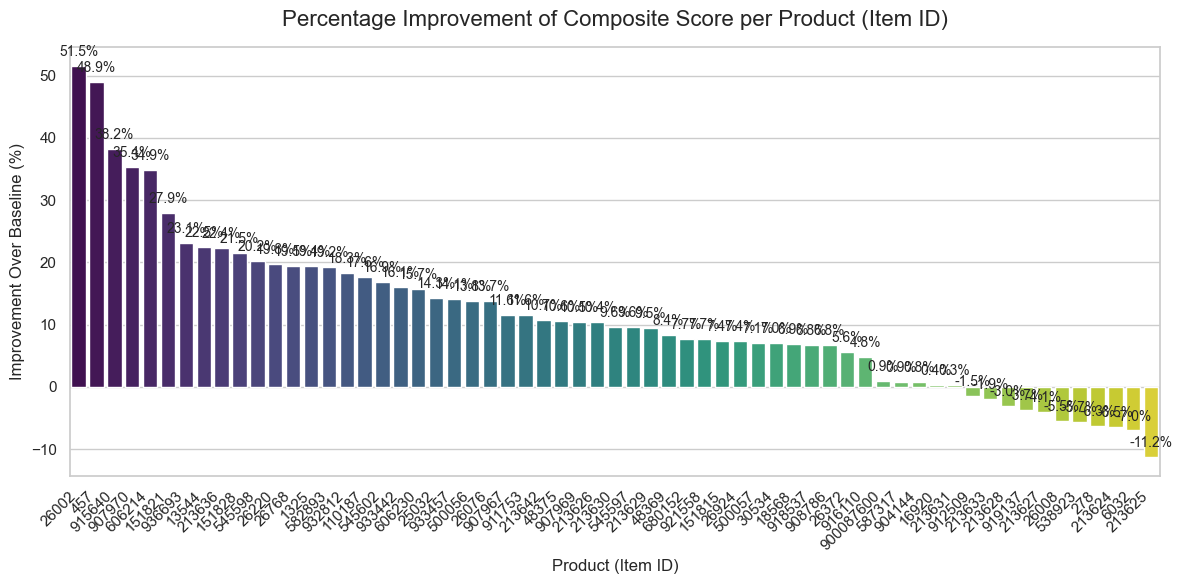

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load your DataFrame (assuming you've already run this)
# gcn_mlp_results_df = pd.read_csv("../GCN/TimedistributedMLP/gcn_mlp_final_results.csv")

# 2. Define the Composite Score
# Example: If lower is better (like an error metric), you might just add RMSE and MAE.
# Adjust this formula based on exactly how you calculate your composite score.
gcn_mlp_results_df['composite_score'] = gcn_mlp_results_df['r2_score']

# 3. Separate Baseline and Experimental models
# Assuming the baseline is the model where ablate_z == True
baseline_df = gcn_mlp_results_df[gcn_mlp_results_df['ablate_z'] == True].copy()
baseline_scores = baseline_df.groupby('item_id')['composite_score'].mean().reset_index()
baseline_scores.rename(columns={'composite_score': 'baseline_score'}, inplace=True)

# 4. Get the best experimental score per item
# Assuming ablate_z == False is the new model, and we want the minimum (best) score per item
experimental_df = gcn_mlp_results_df[gcn_mlp_results_df['ablate_z'] == False].copy()
best_exp_scores = experimental_df.groupby('item_id')['composite_score'].min().reset_index()
best_exp_scores.rename(columns={'composite_score': 'best_experimental_score'}, inplace=True)

# 5. Merge and Calculate Percentage Improvement
improvement_df = pd.merge(baseline_scores, best_exp_scores, on='item_id')

# Formula: ((Baseline - Experimental) / Baseline) * 100
# (Positive percentage means the experimental model's error is lower/better)
improvement_df['pct_improvement'] = (
    (improvement_df['baseline_score'] - improvement_df['best_experimental_score']) 
    / improvement_df['baseline_score']
) * 100

# Sort for a nicer looking plot
improvement_df = improvement_df.sort_values(by='pct_improvement', ascending=False)

# 6. Plotting with Seaborn
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create the barplot
ax = sns.barplot(
    data=improvement_df, 
    x='item_id', 
    y='pct_improvement', 
    palette='viridis',
    order=improvement_df['item_id'] # Ensures bars are sorted
)

# Formatting the plot
plt.title('Percentage Improvement of Composite Score per Product (Item ID)', fontsize=16, pad=15)
plt.xlabel('Product (Item ID)', fontsize=12)
plt.ylabel('Improvement Over Baseline (%)', fontsize=12)

# Rotate x-axis labels if you have many products
plt.xticks(rotation=45, ha='right')

# Add percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd

# 1. Load your DataFrame (assuming you've already run this)
# gcn_mlp_results_df = pd.read_csv("../GCN/TimedistributedMLP/gcn_mlp_final_results.csv")

# 2. Define the Composite Score
# For R2 score, HIGHER is better.
gcn_mlp_results_df['composite_score'] = gcn_mlp_results_df['r2_score']

# 3. Separate Baseline and Experimental models
# Assuming the baseline is the model where ablate_z == True
baseline_df = gcn_mlp_results_df[gcn_mlp_results_df['ablate_z'] == True].copy()
baseline_scores = baseline_df.groupby('item_id')['composite_score'].mean().reset_index()
baseline_scores.rename(columns={'composite_score': 'baseline_score'}, inplace=True)

# 4. Get the best experimental score per item
experimental_df = gcn_mlp_results_df[gcn_mlp_results_df['ablate_z'] == False].copy()
# Note: Because R2 is higher-is-better, we use .max() instead of .min()
best_exp_scores = experimental_df.groupby('item_id')['composite_score'].max().reset_index()
best_exp_scores.rename(columns={'composite_score': 'best_experimental_score'}, inplace=True)

# 5. Merge and Calculate Percentage Improvement
improvement_df = pd.merge(baseline_scores, best_exp_scores, on='item_id')

# Formula for metrics where higher is better: ((Experimental - Baseline) / abs(Baseline)) * 100
improvement_df['pct_improvement'] = (
    (improvement_df['best_experimental_score'] - improvement_df['baseline_score']) 
    / improvement_df['baseline_score'].abs()
) * 100

# Sort so the highest improvements are at the top
improvement_df = improvement_df.sort_values(by='pct_improvement', ascending=False)

# 6. Display as a styled table
# This will render a colored HTML table in your Jupyter Notebook
styled_table = improvement_df.style.format({
    'baseline_score': '{:.4f}',
    'best_experimental_score': '{:.4f}',
    'pct_improvement': '{:+.2f}%' # Adds a + sign for positive improvements
}).background_gradient(
    subset=['pct_improvement'], 
    cmap='RdYlGn', # Red (negative) to Yellow (neutral) to Green (positive)
    vmin=-10,      # Adjust these bounds based on your expected variance
    vmax=10
).set_caption(
    "Percentage Improvement of R2 Score per Product (Item ID)"
).set_table_styles([{
    'selector': 'caption',
    'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]
}]).hide(axis="index")

# Leave the variable at the end of the cell to render it
styled_table

item_id,baseline_score,best_experimental_score,pct_improvement
213625,8.0019,15.0287,+87.82%
213628,12.4854,19.4027,+55.40%
213629,16.6472,23.6457,+42.04%
151815,13.0506,18.3499,+40.61%
213624,7.6566,10.7542,+40.46%
900087600,7.7277,10.8326,+40.18%
919137,12.9298,18.0120,+39.31%
912509,7.3609,10.1274,+37.58%
916110,7.5925,10.3658,+36.53%
278,8.1457,10.8335,+33.00%


In [14]:
import pandas as pd
from IPython.display import display

# 1. Load your DataFrame (assuming you've already run this)
# gcn_mlp_results_df = pd.read_csv("../GCN/TimedistributedMLP/gcn_mlp_final_results.csv")
df = gcn_mlp_results_df.copy()

# Define the metric (Higher is better for R2)
df['composite_score'] = df['r2_score']

# 2. Get the Baseline (Ablation == True)
baseline = df[df['ablate_z'] == True].groupby('item_id')['composite_score'].max().reset_index()
baseline.rename(columns={'composite_score': 'Best_val_for_ablation'}, inplace=True)

# 3. Get Experimental thresholds (Ablation == False) and Pivot
exp = df[df['ablate_z'] == False]
pivot_exp = pd.pivot_table(
    exp, 
    values='composite_score', 
    index='item_id', 
    columns='threshold', 
    aggfunc='max'
).reset_index()

# 4. Merge Baseline and Experimental tables
final_df = pd.merge(baseline, pivot_exp, on='item_id')

# 5. Dynamically calculate relative performance
thresholds = [col for col in pivot_exp.columns if col != 'item_id']

ordered_cols = ['item_id', 'Best_val_for_ablation']
rel_cols_for_styling = [] 

for t in thresholds:
    val_col = f'Best_val_for_threshold_{t}'
    rel_col = f'Relative_Performance_for_threshold_{t}'
    
    final_df.rename(columns={t: val_col}, inplace=True)
    
    final_df[rel_col] = (
        (final_df[val_col] - final_df['Best_val_for_ablation']) 
        / final_df['Best_val_for_ablation'].abs()
    ) * 100
    
    ordered_cols.extend([val_col, rel_col])
    rel_cols_for_styling.append(rel_col)

final_df = final_df[ordered_cols]

# 6. Apply dynamic styling for the detailed table
format_dict = {col: '{:.4f}' for col in final_df.columns if col.startswith('Best_val')}
format_dict.update({col: '{:+.2f}%' for col in rel_cols_for_styling})

styled_table = final_df.style.format(format_dict).background_gradient(
    subset=rel_cols_for_styling, 
    cmap='RdYlGn', 
    vmin=-10, 
    vmax=10
).set_caption(
    "Absolute Scores and Relative Performance per Threshold vs Ablation Baseline"
).set_table_styles([{
    'selector': 'caption',
    'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]
}, {
    'selector': 'th',
    'props': [('text-align', 'center'), ('background-color', '#f4f4f4')]
}]).hide(axis="index")


# --- NEW SECTION: SUMMARY TABLE ---

# 7. Calculate aggregate metrics for each threshold
summary_data = []

# Get the average baseline score just for context
mean_baseline = final_df['Best_val_for_ablation'].mean()

for t in thresholds:
    val_col = f'Best_val_for_threshold_{t}'
    rel_col = f'Relative_Performance_for_threshold_{t}'
    
    mean_score = final_df[val_col].mean()
    mean_improvement = final_df[rel_col].mean()
    # MAPE: Mean of the absolute percentage differences
    mape = final_df[rel_col].abs().mean()
    # Win Rate: What percentage of items saw a positive improvement?
    win_rate = (final_df[rel_col] > 0).mean() * 100 
    
    summary_data.append({
        'Threshold': t,
        'Mean Score (R2)': mean_score,
        'Mean Improvement (%)': mean_improvement,
        'MAPE (%)': mape,
        'Win Rate (%)': win_rate
    })

summary_df = pd.DataFrame(summary_data)

# 8. Style the summary table
styled_summary = summary_df.style.format({
    'Mean Score (R2)': '{:.4f}',
    'Mean Improvement (%)': '{:+.2f}%',
    'MAPE (%)': '{:.2f}%',
    'Win Rate (%)': '{:.1f}%'
}).background_gradient(
    subset=['Mean Improvement (%)', 'Win Rate (%)'], 
    cmap='RdYlGn',
    # Adjust vmin/vmax based on what constitutes a "good" overall average in your domain
    vmin=-2, 
    vmax=2 
).set_caption(
    f"Average Performance Metrics by Threshold (Baseline Avg R2: {mean_baseline:.4f})"
).set_table_styles([{
    'selector': 'caption',
    'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px'), ('color', '#333')]
}, {
    'selector': 'th',
    'props': [('text-align', 'center'), ('background-color', '#e8f4f8')]
}]).hide(axis="index")

# Display both tables sequentially in the output cell
display(styled_table)
display(styled_summary)

item_id,Best_val_for_ablation,Best_val_for_threshold_0.75,Relative_Performance_for_threshold_0.75,Best_val_for_threshold_0.82,Relative_Performance_for_threshold_0.82,Best_val_for_threshold_0.85,Relative_Performance_for_threshold_0.85,Best_val_for_threshold_0.88,Relative_Performance_for_threshold_0.88,Best_val_for_threshold_0.91,Relative_Performance_for_threshold_0.91
110187,57.2765,60.4193,+5.49%,67.9679,+18.67%,57.5426,+0.46%,59.3733,+3.66%,56.8252,-0.79%
1325,7.5847,6.6555,-12.25%,6.5904,-13.11%,8.1733,+7.76%,7.3041,-3.70%,6.2390,-17.74%
13544,34.4194,33.7552,-1.93%,30.8496,-10.37%,33.4658,-2.77%,31.8557,-7.45%,31.6001,-8.19%
151815,13.9355,14.6581,+5.19%,15.5391,+11.51%,14.8187,+6.34%,18.3499,+31.68%,13.5625,-2.68%
151821,14.3746,11.6683,-18.83%,12.8341,-10.72%,11.7136,-18.51%,13.6533,-5.02%,13.8766,-3.46%
151828,12.1370,8.6427,-28.79%,8.2833,-31.75%,8.3758,-30.99%,8.3748,-31.00%,8.5395,-29.64%
16920,7.4168,8.1598,+10.02%,9.1048,+22.76%,8.0150,+8.06%,7.6473,+3.11%,7.5454,+1.73%
18568,18.2814,18.1824,-0.54%,17.5322,-4.10%,18.1487,-0.73%,18.0277,-1.39%,18.2998,+0.10%
213624,8.0689,8.6588,+7.31%,10.7542,+33.28%,9.5469,+18.32%,8.7411,+8.33%,9.4063,+16.57%
213625,8.3021,10.6644,+28.45%,12.6040,+51.82%,15.0287,+81.02%,11.5666,+39.32%,13.4380,+61.86%


Threshold,Mean Score (R2),Mean Improvement (%),MAPE (%),Win Rate (%)
0.750000,15.0279,+3.28%,13.08%,59.0%
0.820000,14.8912,+1.39%,12.76%,45.9%
0.850000,14.6485,+1.22%,12.26%,49.2%
0.880000,14.4508,-0.63%,10.74%,42.6%
0.910000,14.6399,+0.43%,12.91%,42.6%
